In [1]:
import csv
import json
import os
import random
import time
from os import listdir
from os.path import join, isdir
from pathlib import Path

import kagglehub
import pandas as pd
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Subset

from src.dataset import TmpCifarDataset, define_transformations, build_train_transformations
from src.metrics import plot_training_metrics
from src.model import SimpleCNN
from src.training import training_loop



/Users/vyankov/Documents/deep-learning/cnn-cifar10-from-scratch/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: MPS (Apple Silicon GPU)


In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using device: CUDA")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"Using device: MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print(f"Using device: CPU")

Using device: MPS (Apple Silicon GPU)


In [3]:
with open("../configs/data_split.json", encoding="utf-8") as file:
    split = json.load(file)

In [4]:
with open("../configs/data_stats.json", encoding="utf-8") as file:
    stats = json.load(file)
mean = stats["mean"]
std = stats["std"]

In [5]:
with open("../configs/base_config.json", encoding="utf-8") as file:
    config_json = json.load(file)

seed = int(config_json["seed"])

batch_size = int(config_json["data"]["batch_size"])
augmentation = config_json["data"]["augmentation"]

model = config_json["model"]["name"]
dropout = config_json["model"]["dropout"]

learning_rate = float(config_json["training"]["learning_rate"])
weight_decay = float(config_json["training"]["weight_decay"])
epochs = int(config_json["training"]["epochs"])

In [6]:
random.seed(seed)
torch.manual_seed(1)

In [7]:
dataset_path = kagglehub.competition_download('cifar-10')
labels_path = os.path.join(dataset_path, 'trainLabels.csv')
train_path = os.path.join(dataset_path, 'train')

In [8]:
cifar_pd = pd.read_csv("../data/processed/cifar10_metadata.csv")

In [9]:

train_transform, val_transform = define_transformations(augmentation, mean, std)

# Reuse the exact indices used for the statistics split.
train_dataset = TmpCifarDataset(train_path, cifar_pd, transform=train_transform)
val_dataset = TmpCifarDataset(train_path, cifar_pd, transform=val_transform)
train_subset = Subset(train_dataset, split["train_indices"])
val_subset = Subset(val_dataset, split["val_indices"])

train_data_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_data_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

In [10]:
verify_simple_cnn = SimpleCNN(num_classes=10, dropout=dropout)
print("Model Structure:\n")
print(verify_simple_cnn)

Model Structure:

SimpleCNN(
  (conv_block1): CNNBlock(
    (block): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (conv_block2): CNNBlock(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.6, inplace=False)
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [11]:
# Create a dummy input tensor (batch_size=64, channels=3, height=32, width=32)
dummy_input = torch.randn(64, 3, 32, 32)
print(f"\nInput tensor shape:  {dummy_input.shape}")
# Pass the dummy tensor through the model
output = verify_simple_cnn(dummy_input)
print(f"Output tensor shape: {output.shape}")


Input tensor shape:  torch.Size([64, 3, 32, 32])
Output tensor shape: torch.Size([64, 10])


In [12]:
num_classes = len(train_dataset.labels.value_counts())
print(f"{num_classes} classes found.")
model = SimpleCNN(num_classes=num_classes, dropout=dropout)

10 classes found.


In [13]:
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

In [14]:
def prepare_results_dir():
    results_dir = "../experiments"
    Path(results_dir).mkdir(parents=True, exist_ok=True)
    experiment_numbers = [
        int(name) for name in listdir(results_dir)
            if name.isdigit() and isdir(join(results_dir, name))
    ]
    exp_number = max(experiment_numbers, default=0) + 1
    exp_path = os.path.join(results_dir, str(exp_number))
    Path(exp_path).mkdir(parents=True, exist_ok=True)
    return results_dir, exp_number, exp_path

In [15]:
results_dir, exp_number, exp_path = prepare_results_dir()
print("Results Directory:", results_dir)
print("Experiment Number:", exp_number)
print("Experiment Path:", exp_path)

Results Directory: ../experiments
Experiment Number: 12
Experiment Path: ../experiments/12


In [16]:
trained_model, training_metrics = training_loop(
    model=model,
    train_loader=train_data_loader,
    val_loader=val_data_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    num_epochs=epochs,
    device=device
)

--- Training Started ---
Epoch [1/1], Train Loss: 1.6107, Train Accuracy: 41.87% Val Loss: 1.2826, Val Accuracy: 54.05%
--- Finished Training ---

--- Returning best model with 54.05% validation accuracy, achieved at epoch 1 ---



--- Training Plots ---



/Users/vyankov/Documents/deep-learning/cnn-cifar10-from-scratch/src/metrics.py:72: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left=1, right=num_epochs)


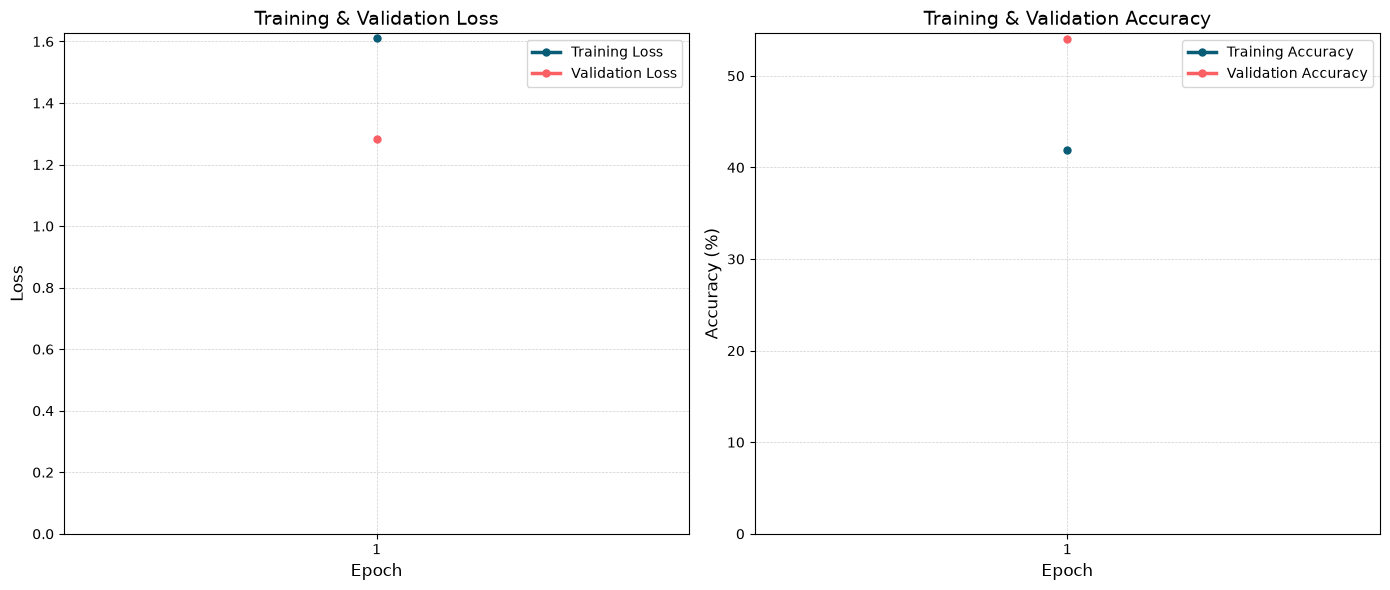

In [17]:
print("\n--- Training Plots ---\n")
plot_training_metrics(training_metrics, exp_path)

In [18]:
def save_results(results_dir,
                 exp_number,
                 learning_rate,
                 metrics,
                 model_name,
                 epoch,
                 batch_size,
                 optimizer,
                 weight_decay,
                 seed,
                 augmentation,
                 config_json):
    train_losses, val_losses, val_accuracies, train_accuracy = metrics
    best_index = max(range(len(val_accuracies)), key=val_accuracies.__getitem__)
    best_val_accuracy = val_accuracies[best_index]
    best_val_loss = val_losses[best_index]
    best_epoch = best_index + 1

    val_accuracy = max(val_accuracies)
    val_loss = min(val_losses)

    save_summary(results_dir, exp_number, learning_rate, val_accuracy, model_name, epoch, batch_size, optimizer, weight_decay, seed, augmentation, val_loss, best_val_accuracy, best_val_loss, best_epoch)
    save_config(exp_path, config_json)

def save_summary(save_path,
                 exp_number,
                 learning_rate,
                 val_accuracy,
                 model_name,
                 epoch,
                 batch_size,
                 optimizer,
                 weight_decay,
                 seed,
                 augmentation,
                 val_loss,
                 best_val_accuracy,
                 best_val_loss,
                 best_epoch):
    summary = {
        "Experiment": f"Exp #{str(exp_number)}",
        "Timestamp": time.strftime("%d/%m/%Y %H:%M:%S", time.localtime()),
        "Model": model_name,
        "Epochs Trained": epoch,
        "Batch Size": batch_size,
        "Optimizer": optimizer,
        "Learning Rate": learning_rate,
        "Weight Decay": weight_decay,
        "Seed": seed,
        "Final Val accuracy": val_accuracy,
        "Final Val loss": val_loss,
        "Best val accuracy": best_val_accuracy,
        "Best val loss": best_val_loss,
        "Best val epoch": best_epoch,
        "Augmentation": augmentation,
    }
    summary_path = os.path.join(save_path, "summary.csv")

    file_exists = os.path.isfile(summary_path)
    with open(summary_path, "a", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=summary.keys())

        if not file_exists:
            writer.writeheader()

        writer.writerow(summary)

def save_config(path, config_json):
    config_path = os.path.join(path, "config.json")
    with open(config_path, "a", newline="", encoding="utf-8") as f:
        json.dump(config_json, f)


In [19]:
save_results(results_dir,
             exp_number,
             learning_rate,
             training_metrics,
             model.__class__.__name__,
             epochs,
             batch_size,
             optimizer.__class__.__name__,
             weight_decay,
             seed,
             "RandomHorizontalFlip(p=0.5) + RandomRotation(15)",
             config_json
             )